# MobiFall — AFD-CNN Training Notebook (4 s Windows: Peak for Falls, Random for ADLs)

Trains the AFD-CNN on the **MobiFall / MobiAct** dataset using the same model architecture and class mapping as the SisFall 4 s model.

**Input representation:** 4 s window (400 samples @ 100 Hz) across 3 accelerometer axes → 400 × 3 = **1200 values** fed directly to the CNN (no repeat).

### Windowing strategy

**Fall class (label 0):** one window per recording, centred on the global-maximum peak of ‖a‖ across the full recording.  The peak naturally falls at impact, so no separate fall-event annotation is needed.

**ADL classes:** one randomly-positioned 4 s window per recording.

### Preprocessing
- MobiFall accelerometer is in m/s²; converted to g (÷ 9.81).
- Resampled 200 → 100 Hz via `resample_poly`.
- Normalised to [0, 255] matching SisFall ADXL345 encoding: `(g × 256 + 4096) / 8192 × 255`.

### Per-class balancing
| Situation | Action |
|---|---|
| candidates ≥ TARGET | randomly sample TARGET without replacement |
| candidates < TARGET | keep all + random oversample with replacement to reach TARGET |

Checkpoint → `model/mobifall_peak4s_random_balanced_model.ckpt`  
CSVs → `data/mobifall_peak4s_random_balanced_{train,test}.csv`

**MobiFall activity → class mapping:**

| MobiFall codes | Class label | Activity |
|---|---|---|
| FOL, FKL, BSC, SDL | 0 | **Fall** |
| WAL | 2 | Walk |
| JOG | 3 | Jog |
| JUM | 4 | Jump |
| STU | 5 | Up-stairs |
| STN | 6 | Down-stairs |
| SCH | 7 | Stand→Sit |
| CHU | 9 | Sit→Stand |

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import resample_poly
from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

I0000 00:00:1776960495.909535   76369 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [2]:
ANN_PATH        = 'MobiFall_dataset/Annotated Data'
MODEL_SAVE_PATH = 'model/mobifall_peak4s_random_balanced_model.ckpt'
TRAIN_CSV       = 'data/mobifall_peak4s_random_balanced_train.csv'
TEST_CSV        = 'data/mobifall_peak4s_random_balanced_test.csv'

FS_IN  = 200   # MobiFall sample rate (Hz)
FS_OUT = 100   # AFD-CNN training rate (Hz)
WINDOW = 400   # samples at 100 Hz = 4 s  (400 × 3 = 1200 values)
HALF_WINDOW = WINDOW // 2

TARGET_COUNT = 298   # max windows per class; matches SisFall model
TEST_SIZE    = 0.20
RANDOM_SEED  = 42

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand',
}

FALL_CODES    = ['FOL', 'FKL', 'BSC', 'SDL']
MOBI_TO_CLASS = {
    'WAL': 2, 'JOG': 3, 'JUM': 4,
    'STU': 5, 'STN': 6, 'SCH': 7, 'CHU': 9,
}

# Phase background colours for visualisation
PHASE_COLORS = {
    'STD': '#cccccc',
    'LYI': '#aaaaff',
    'SIT': '#ffffaa',
    **{c: '#ffaaaa' for c in FALL_CODES},
    **{c: '#aaffaa' for c in MOBI_TO_CLASS},
}

print('Classes:', CLASS_LIST)
print('Fall codes:', FALL_CODES)
print('ADL codes:', list(MOBI_TO_CLASS.keys()))
print(f'Window: {WINDOW} samples = {WINDOW / FS_OUT:.0f} s at {FS_OUT} Hz  \u2192  {WINDOW * 3} values per sample')
print(f'Configured target per class: {TARGET_COUNT}')

Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Fall codes: ['FOL', 'FKL', 'BSC', 'SDL']
ADL codes: ['WAL', 'JOG', 'JUM', 'STU', 'STN', 'SCH', 'CHU']
Window: 400 samples = 4 s at 100 Hz  →  1200 values per sample
Configured target per class: 298


## 3. Helper Functions

In [3]:
def load_and_preprocess(filepath):
    """
    Load a MobiFall annotated CSV and return (arr_norm, labels) at FS_OUT Hz.

    Pipeline
    --------
    1. Read acc_x/y/z columns (m/s²)
    2. m/s² → g  (÷ 9.81)
    3. Polyphase resample FS_IN → FS_OUT
    4. ADXL345 normalization: (g × 256 + 4096) / 8192 × 255  → [0, 255]
    5. Decimate label column to FS_OUT via simple stride
    """
    df      = pd.read_csv(filepath)
    arr_g   = df[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32) / 9.81
    arr_100 = resample_poly(arr_g, FS_OUT, FS_IN, axis=0).astype(np.float32)
    adc     = arr_100 * 256.0
    arr_norm = np.clip((adc + 4096.0) / 8192.0 * 255.0, 0.0, 255.0).astype(np.float32)
    labels   = df['label'].to_numpy()[::2][:len(arr_norm)]
    return arr_norm, labels


def extract_peak_window(arr, window=WINDOW):
    """
    Single max-peak window from arr (T, 3), centred on the sample with the
    highest vector magnitude ‖a‖.  Clamped to recording boundaries.
    Returns (window_arr, peak_idx) or (None, None) if arr is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    mag      = np.linalg.norm(arr, axis=1)
    peak_idx = int(np.argmax(mag))
    start    = max(0, min(peak_idx - window // 2, n - window))
    return arr[start: start + window], peak_idx


def extract_random_window(arr, window=WINDOW, rng=None):
    """
    Single randomly-positioned window from arr (T, 3).
    Returns (window_arr, start_idx) or (None, None) if arr is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    max_start = n - window
    start = int(rng.integers(0, max_start + 1)) if rng is not None else np.random.randint(0, max_start + 1)
    return arr[start: start + window], start


print('Helper functions defined.')

Helper functions defined.


## 4. Collect Windows and Balance Classes

Falls use the **full recording** — peak centering on max ‖a‖ naturally selects the impact window.  
ADLs use one **randomly-positioned** 4 s window per recording.  
Both sets are then balanced to the same TARGET count.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)

candidate_windows = {lbl: [] for lbl in CLASS_LIST}
recording_counts  = {lbl: 0 for lbl in CLASS_LIST}
skip_counts       = {lbl: 0 for lbl in CLASS_LIST}

# ── Falls (class 0): peak-centred on full recording ───────────────────────
for code in FALL_CODES:
    code_dir = os.path.join(ANN_PATH, code)
    for fname in sorted(f for f in os.listdir(code_dir) if f.endswith('.csv')):
        arr_norm, _ = load_and_preprocess(os.path.join(code_dir, fname))
        recording_counts[0] += 1
        win, _ = extract_peak_window(arr_norm, window=WINDOW)
        if win is not None:
            candidate_windows[0].append(win.flatten().astype(np.float32))
        else:
            skip_counts[0] += 1

# ── ADLs: one random window per recording ─────────────────────────────────
for code, cls_id in MOBI_TO_CLASS.items():
    code_dir = os.path.join(ANN_PATH, code)
    if not os.path.isdir(code_dir):
        print(f'{code}: directory not found, skipping')
        continue
    for fname in sorted(f for f in os.listdir(code_dir) if f.endswith('.csv')):
        arr_norm, _ = load_and_preprocess(os.path.join(code_dir, fname))
        recording_counts[cls_id] += 1
        win, _ = extract_random_window(arr_norm, window=WINDOW, rng=rng)
        if win is not None:
            candidate_windows[cls_id].append(win.flatten().astype(np.float32))
        else:
            skip_counts[cls_id] += 1

# ── Balance every class to TARGET samples ─────────────────────────────────
n_falls = len(candidate_windows[0])
TARGET  = min(n_falls, TARGET_COUNT)
if TARGET < 2:
    raise ValueError(f'Not enough fall windows: n_falls={n_falls}')

print(f'Fall peak windows collected: {n_falls}  \u2192  TARGET = {TARGET}')
print()

X_acc_list = []
y_list     = []

print(f'{'Class':<14}  {'Recordings':>10}  {'Candidates':>11}  {'Skipped':>8}  {'Balanced':>9}  {'Oversampled':>12}')
print('-' * 72)

for lbl in CLASS_LIST:
    windows = candidate_windows[lbl]
    n_cand  = len(windows)
    if n_cand == 0:
        raise ValueError(f'No candidate windows for class {lbl} ({CLASS_NAMES[lbl]})')

    if n_cand >= TARGET:
        chosen_idxs = rng.choice(n_cand, size=TARGET, replace=False)
        n_over = 0
    else:
        extra_idxs  = rng.choice(n_cand, size=TARGET - n_cand, replace=True)
        chosen_idxs = np.concatenate([np.arange(n_cand), extra_idxs])
        n_over = TARGET - n_cand

    chosen_idxs = rng.permutation(chosen_idxs)
    for idx in chosen_idxs:
        X_acc_list.append(windows[int(idx)])
        y_list.append(lbl)

    print(f'{CLASS_NAMES[lbl]:<14}  {recording_counts[lbl]:>10}  {n_cand:>11}  '
          f'{skip_counts[lbl]:>8}  {TARGET:>9}  {n_over:>12}')

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 1200)
y     = np.array(y_list, dtype=int)

print()
print(f'Total windows after balancing: {len(X_acc)}  ({len(CLASS_LIST)} classes × {TARGET})')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')

Fall peak windows collected: 767  →  TARGET = 298

Class           Recordings   Candidates   Skipped   Balanced   Oversampled
------------------------------------------------------------------------
Fall                   767          767         0        298             0
Walk                    61           61         0        298           237
Jog                    183          183         0        298           115
Jump                   183          183         0        298           115
Up-stairs              364          364         0        298             0
Down-stairs            365          365         0        298             0
Stand→Sit              365          365         0        298             0
Sit→Stand              114          114         0        298           184

Total windows after balancing: 2384  (8 classes × 298)
Sensor value range: [111.4, 143.6]


## 5. Visualise Peak Detection and Random Window

**Fall recording:** full signal, background coloured by phase label (grey=STD, red=fall event, blue=LYI).  
Peak (gold dashed line) and selected 4 s window (gold shading) are marked.

**ADL recording:** full signal with randomly-positioned 4 s window shaded.

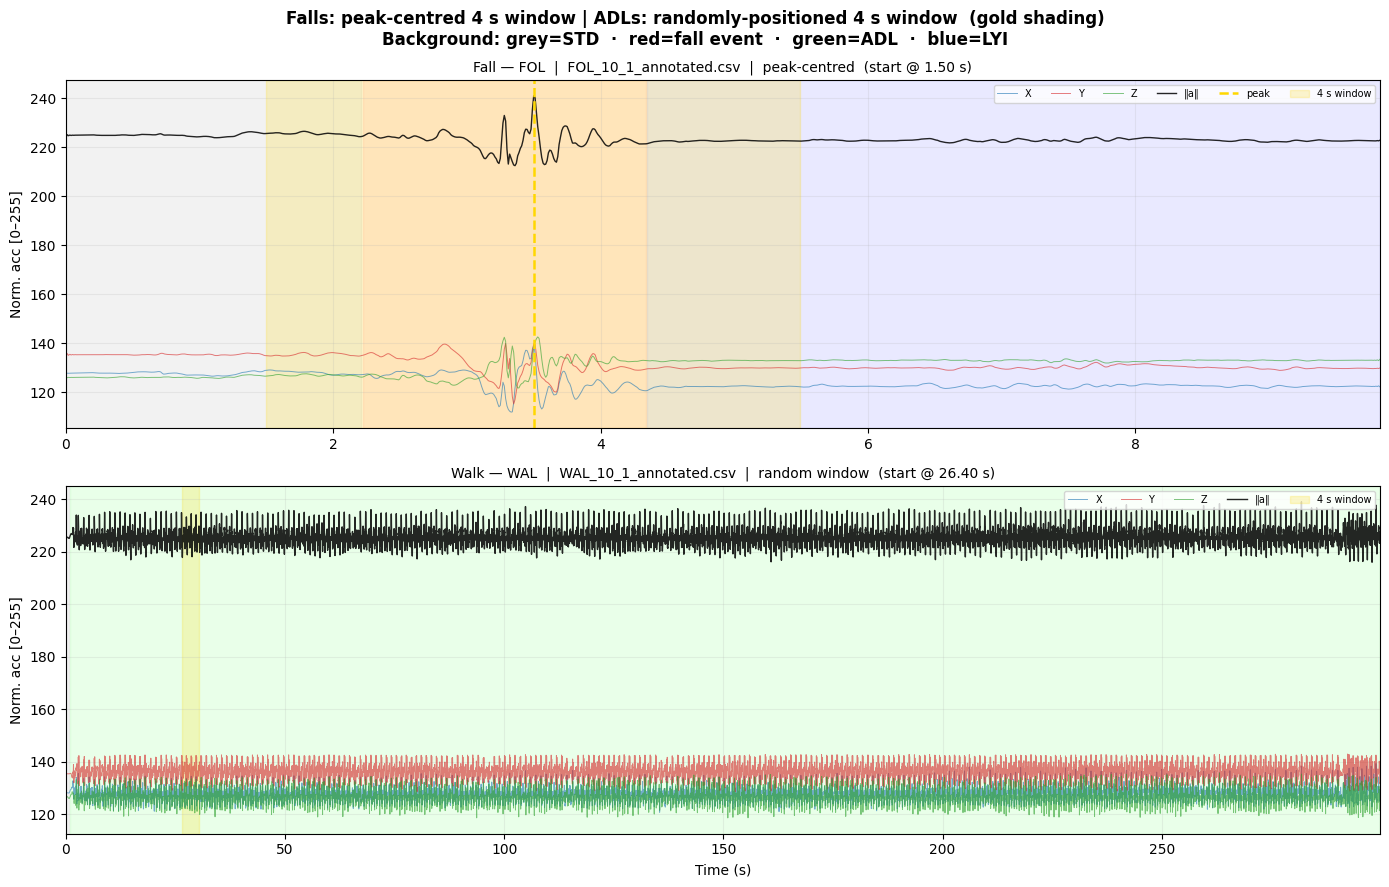

In [5]:
def load_recording_for_vis(code, lbl, rng_vis):
    code_dir = os.path.join(ANN_PATH, code)
    for fname in sorted(f for f in os.listdir(code_dir) if f.endswith('.csv')):
        arr_norm, labels = load_and_preprocess(os.path.join(code_dir, fname))
        if len(arr_norm) < WINDOW:
            continue
        if lbl == 0:
            win, peak_idx = extract_peak_window(arr_norm, window=WINDOW)
            if win is None:
                continue
            start_idx = max(0, min(peak_idx - HALF_WINDOW, len(arr_norm) - WINDOW))
            return arr_norm, labels, peak_idx, start_idx, 'peak-centred', fname
        else:
            win, start_idx = extract_random_window(arr_norm, window=WINDOW, rng=rng_vis)
            if win is None:
                continue
            return arr_norm, labels, start_idx + HALF_WINDOW, start_idx, 'random window', fname
    return None, None, None, None, None, None


vis_rng     = np.random.default_rng(RANDOM_SEED)
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']
AXIS_NAMES  = ['X', 'Y', 'Z']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, (code, lbl, title_tag) in zip(axes, [
    ('FOL', 0, 'Fall \u2014 FOL'),
    ('WAL', 2, 'Walk \u2014 WAL'),
]):
    arr_norm, labels, peak_idx, start_idx, marker_label, fname = load_recording_for_vis(
        code, lbl, vis_rng
    )
    if arr_norm is None:
        ax.set_title(f'{title_tag}: no file found')
        continue

    t   = np.arange(len(arr_norm)) / float(FS_OUT)
    mag = np.linalg.norm(arr_norm, axis=1)

    # Background shading by phase
    if labels is not None:
        seg_start = 0
        prev_lbl  = labels[0]
        for i in range(1, len(labels) + 1):
            cur_lbl = labels[i] if i < len(labels) else None
            if cur_lbl != prev_lbl:
                color = PHASE_COLORS.get(prev_lbl, '#eeeeee')
                ax.axvspan(t[seg_start], t[min(i - 1, len(t) - 1)],
                           alpha=0.25, color=color, zorder=0)
                seg_start = i
                prev_lbl  = cur_lbl

    for a in range(3):
        ax.plot(t, arr_norm[:, a], color=AXIS_COLORS[a], lw=0.7, alpha=0.6, label=AXIS_NAMES[a])
    ax.plot(t, mag, color='black', lw=1.0, alpha=0.85, label='\u2016a\u2016')

    if lbl == 0:
        ax.axvline(t[peak_idx], color='gold', lw=1.8, ls='--', label='peak')
    ax.axvspan(t[start_idx], t[start_idx + WINDOW - 1], alpha=0.20, color='gold', label='4 s window')

    ax.set_xlim(0, t[-1])
    ax.set_title(f'{title_tag}  |  {fname}  |  {marker_label}  (start @ {t[start_idx]:.2f} s)', fontsize=10)
    ax.set_ylabel('Norm. acc [0\u2013255]')
    ax.legend(fontsize=7, ncol=7, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(
    'Falls: peak-centred 4 s window | ADLs: randomly-positioned 4 s window  (gold shading)\n'
    'Background: grey=STD  \u00b7  red=fall event  \u00b7  green=ADL  \u00b7  blue=LYI',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 6. Visualise Sample Windows

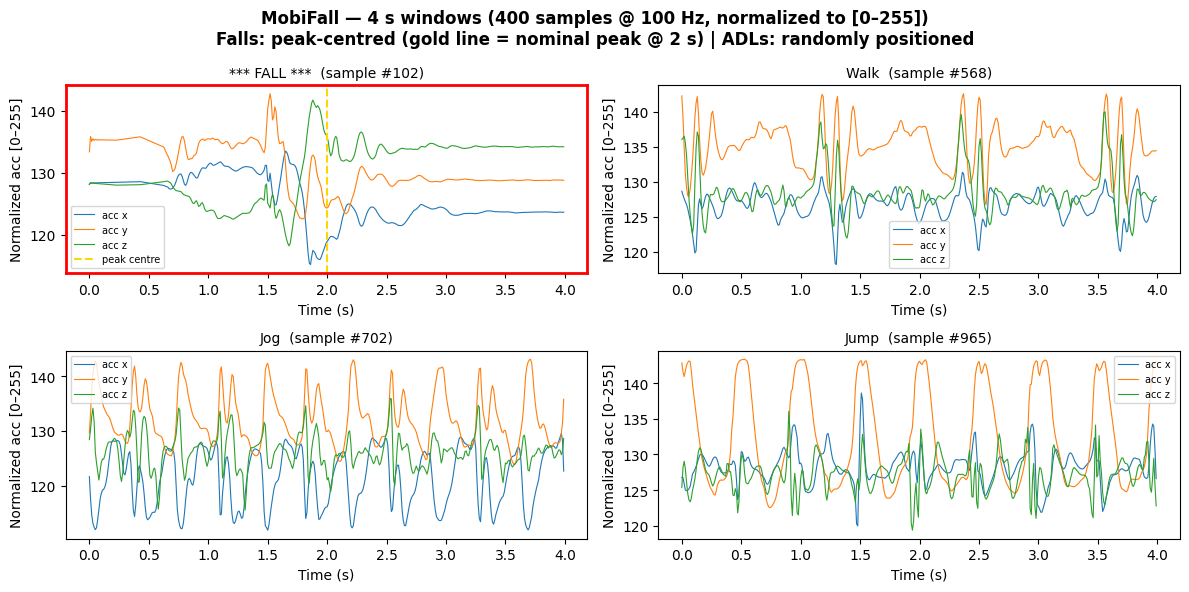

In [6]:
np.random.seed(RANDOM_SEED)
show_labels = [0, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(WINDOW, 3)
    t        = np.arange(WINDOW) / float(FS_OUT)
    for i, (aname, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, lw=0.8, label=f'acc {aname}')
    if label == 0:
        ax.axvline(2.0, color='gold', lw=1.5, ls='--', label='peak centre')
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (sample #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0\u2013255]')
    ax.legend(fontsize=7)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'MobiFall \u2014 4 s windows (400 samples @ 100 Hz, normalized to [0\u2013255])\n'
    'Falls: peak-centred (gold line = nominal peak @ 2 s) | ADLs: randomly positioned',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

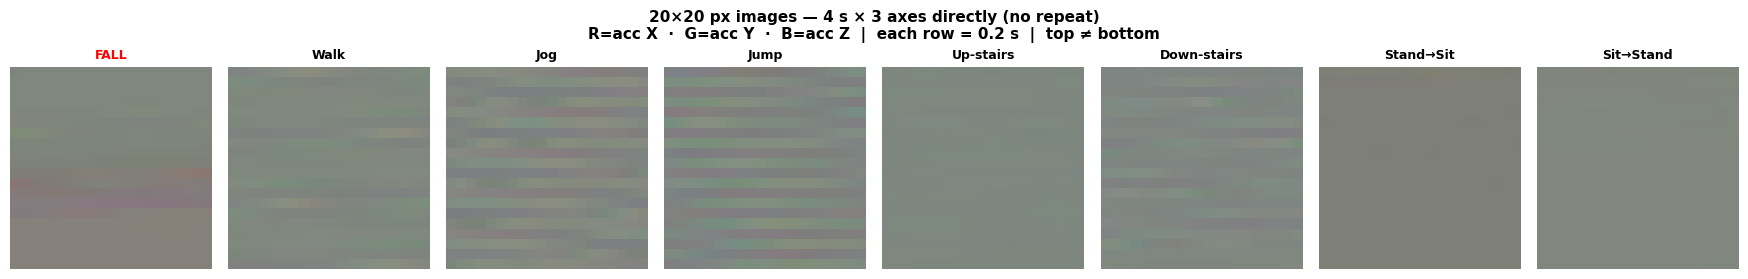

In [7]:
def to_image(acc_flat):
    """Reshape 1200-value vector directly to 20×20×3 image in [0, 1]."""
    return acc_flat.reshape(20, 20, 3) / 255.0


np.random.seed(7)
fig, axes = plt.subplots(1, len(CLASS_LIST), figsize=(2.2 * len(CLASS_LIST), 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    ax.imshow(to_image(X_acc[sample_i]))
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle(
    '20\u00d720 px images \u2014 4 s \u00d7 3 axes directly (no repeat)\n'
    'R=acc X  \u00b7  G=acc Y  \u00b7  B=acc Z  |  each row = 0.2 s  |  top \u2260 bottom',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 7. Equal Per-Class Train / Test Split and Save CSVs

The split is performed independently within each label so every category is balanced in both the training and test sets.

In [8]:
split_rng = np.random.default_rng(RANDOM_SEED)

TEST_PER_CLASS  = int(round(TARGET * TEST_SIZE))
TEST_PER_CLASS  = max(1, min(TARGET - 1, TEST_PER_CLASS))
TRAIN_PER_CLASS = TARGET - TEST_PER_CLASS

train_indices = []
test_indices  = []

for lbl in CLASS_LIST:
    idxs = np.where(y == lbl)[0]
    if len(idxs) != TARGET:
        raise ValueError(f'Class {lbl} has {len(idxs)} samples; expected {TARGET}')
    idxs = split_rng.permutation(idxs)
    test_indices.extend(idxs[:TEST_PER_CLASS])
    train_indices.extend(idxs[TEST_PER_CLASS:TEST_PER_CLASS + TRAIN_PER_CLASS])

idx_train = split_rng.permutation(np.array(train_indices, dtype=int))
idx_test  = split_rng.permutation(np.array(test_indices,  dtype=int))

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print(f'Per class: train={TRAIN_PER_CLASS}, test={TEST_PER_CLASS}')
print()
print(f'{'Class':>14}  {'Train':>7}  {'Test':>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>14}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')

Train: 1904 samples | Test: 480 samples
Per class: train=238, test=60

         Class    Train    Test
--------------------------------
          Fall      238      60
          Walk      238      60
           Jog      238      60
          Jump      238      60
     Up-stairs      238      60
   Down-stairs      238      60
     Stand→Sit      238      60
     Sit→Stand      238      60


In [9]:
col_names = ['label'] + [str(i + 1) for i in range(WINDOW * 3)]

train_df = pd.DataFrame(np.column_stack([y_train.astype(float), X_acc_train]), columns=col_names)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(np.column_stack([y_test.astype(float), X_acc_test]), columns=col_names)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows, {WINDOW * 3} values each)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows, {WINDOW * 3} values each)')

Saved  data/mobifall_peak4s_random_balanced_train.csv  (1904 rows, 1200 values each)
Saved  data/mobifall_peak4s_random_balanced_test.csv   (480 rows, 1200 values each)


## 8. Build Model Inputs

No repeat needed — the 4 s window already produces 400 × 3 = **1200 values** per sample, matching the CNN's expected input shape exactly.

In [10]:
def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh


X_model_train = X_acc_train.astype(np.float32)   # (N_train, 1200)
X_model_test  = X_acc_test.astype(np.float32)    # (N_test,  1200)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Train input: {X_model_train.shape}  |  Test input: {X_model_test.shape}')
print(f'Value range: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Train input: (1904, 1200)  |  Test input: (480, 1200)
Value range: [111.4, 143.6]


## 9. Build TF Graph and Train

In [11]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op    = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits))
train_op   = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op     = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op   = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built. Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built. Training on 1904 samples for 5000 steps...


E0000 00:00:1776960524.409437   76369 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776960524.415901   76369 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [12]:
n_train = len(X_model_train)
perm    = np.random.permutation(n_train)
ptr     = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0
    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    _, loss_val = sess.run(
        [train_op, loss_op],
        feed_dict={x_ph: X_model_train[batch_idx],
                   y_ph: y_train_oh[batch_idx],
                   keep_prob_ph: 0.5},
    )
    if step % 500 == 0:
        acc_val = acc_op.eval(
            session=sess,
            feed_dict={x_ph: X_model_train[batch_idx],
                       y_ph: y_train_oh[batch_idx],
                       keep_prob_ph: 1.0},
        )
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.1490  |  batch acc = 0.9600
Step  1000  |  loss = 0.0385  |  batch acc = 1.0000
Step  1500  |  loss = 0.0313  |  batch acc = 1.0000
Step  2000  |  loss = 0.0078  |  batch acc = 1.0000
Step  2500  |  loss = 0.0011  |  batch acc = 1.0000
Step  3000  |  loss = 0.0011  |  batch acc = 1.0000
Step  3500  |  loss = 0.0003  |  batch acc = 1.0000
Step  4000  |  loss = 0.0093  |  batch acc = 1.0000
Step  4500  |  loss = 0.0002  |  batch acc = 1.0000
Step  5000  |  loss = 0.0000  |  batch acc = 1.0000

Model saved to model/mobifall_peak4s_random_balanced_model.ckpt


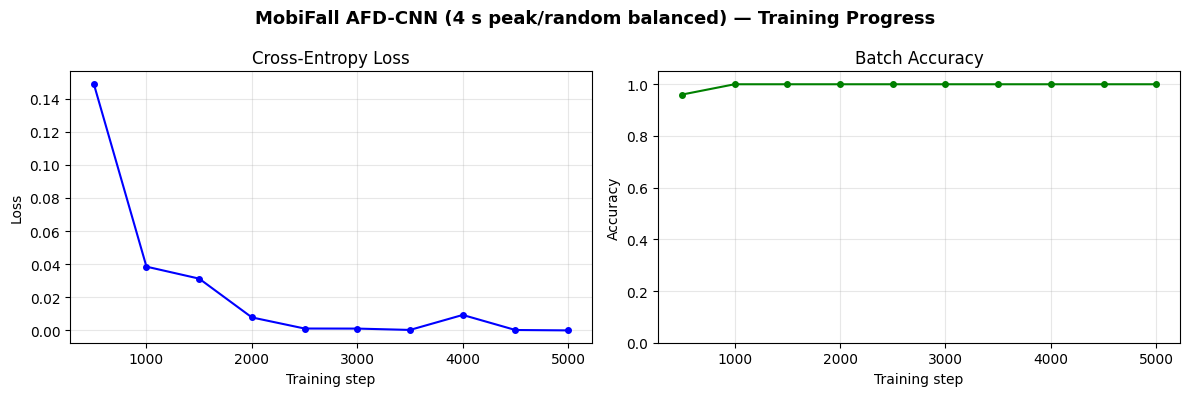

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('MobiFall AFD-CNN (4 s peak/random balanced) \u2014 Training Progress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Evaluate on Train and Test Sets

In [14]:
def run_inference(X):
    EVAL_BATCH = 256
    all_logits_list = []
    all_probs_list  = []
    for start in range(0, len(X), EVAL_BATCH):
        l, p = sess.run(
            [logits, probs_op],
            feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0},
        )
        all_logits_list.append(l)
        all_probs_list.append(p)
    all_logits_out  = np.vstack(all_logits_list)
    all_probs_out   = np.vstack(all_probs_list)
    pred_idx        = np.argmax(all_probs_out, axis=1)
    pred_labels     = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs_out, all_logits_out


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{'Class':>14}  {'N':>5}  {'Sensitivity':>12}  {'Specificity':>12}')
    print('-' * 50)
    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>14}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (1904 samples) ===
Overall accuracy: 1.0000  (100.00%)
         Class      N   Sensitivity   Specificity
--------------------------------------------------
          Fall    238        1.0000        1.0000
          Walk    238        1.0000        1.0000
           Jog    238        1.0000        1.0000
          Jump    238        1.0000        1.0000
     Up-stairs    238        1.0000        1.0000
   Down-stairs    238        1.0000        1.0000
     Stand→Sit    238        1.0000        1.0000
     Sit→Stand    238        1.0000        1.0000

=== Test set (480 samples) ===
Overall accuracy: 0.9750  (97.50%)
         Class      N   Sensitivity   Specificity
--------------------------------------------------
          Fall     60        1.0000        1.0000
          Walk     60        1.0000        0.9976
           Jog     60        0.9833        0.9976
          Jump     60        0.9833        0.9976
     Up-stairs     60        0.9333        0.9929
   Down-stai

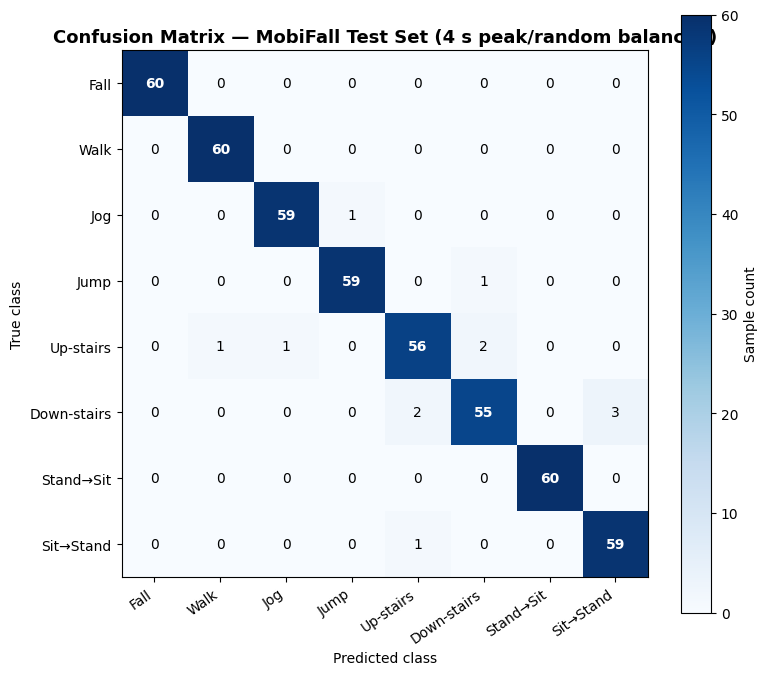

In [15]:
pred_test, _, _ = run_inference(X_model_test)
label_names     = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')
ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title(
    'Confusion Matrix \u2014 MobiFall Test Set (4 s peak/random balanced)',
    fontsize=13, fontweight='bold',
)
for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

## 11. Fall Logit and P(Fall) Distributions by True Label

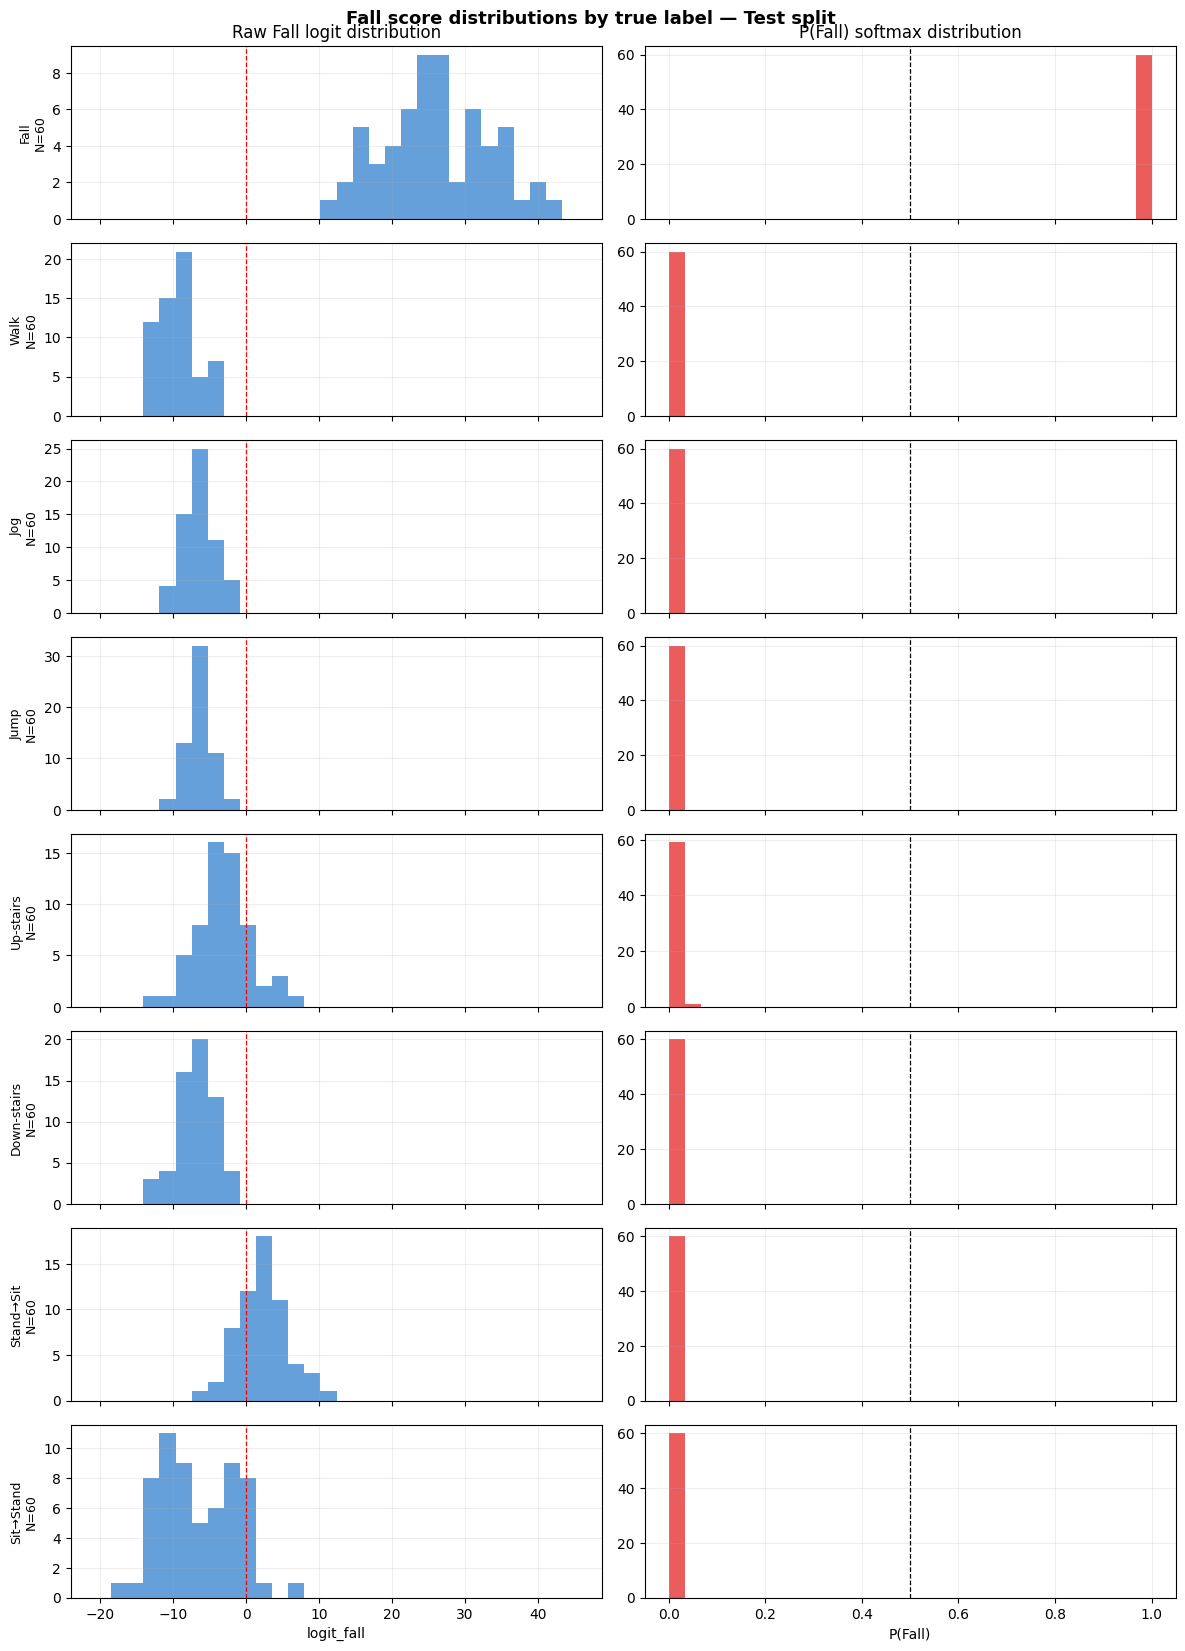

=== Fall score distribution summary ===
 label  class_name  n  mean_logit_fall  median_logit_fall  mean_prob_fall  median_prob_fall  max_prob_fall
     0        Fall 60        25.829977          25.620018    9.998857e-01      9.999999e-01   9.999999e-01
     2        Walk 60        -9.379483          -9.597304    1.265133e-08      1.875499e-12   2.437908e-07
     3         Jog 60        -6.567594          -6.924599    2.706648e-08      2.891688e-12   1.574266e-06
     4        Jump 60        -6.318621          -6.364714    9.846334e-10      1.302173e-13   3.316421e-08
     5   Up-stairs 60        -3.032458          -3.142906    7.702693e-04      5.407794e-09   4.539531e-02
     6 Down-stairs 60        -6.784331          -6.913982    8.004868e-05      5.283980e-09   3.586984e-03
     7   Stand→Sit 60         2.261202           2.244616    3.605589e-06      1.839881e-09   1.423326e-04
     9   Sit→Stand 60        -6.710541          -7.749245    1.406871e-08      1.186411e-13   6.504146e-

In [16]:
DIST_SPLIT = 'Test'
X_dist = X_model_test if DIST_SPLIT == 'Test' else X_model_train
y_dist = y_test        if DIST_SPLIT == 'Test' else y_train

_, dist_probs, dist_logits = run_inference(X_dist)
fall_idx = CLASS_LIST.index(0)

dist_df = pd.DataFrame({
    'label':      y_dist,
    'class_name': [CLASS_NAMES[int(lbl)] for lbl in y_dist],
    'logit_fall': dist_logits[:, fall_idx],
    'prob_fall':  dist_probs[:, fall_idx],
})

logit_min, logit_max = dist_df['logit_fall'].min(), dist_df['logit_fall'].max()
if np.isclose(logit_min, logit_max):
    logit_min -= 1.0; logit_max += 1.0
logit_pad  = 0.05 * (logit_max - logit_min)
logit_bins = np.linspace(logit_min - logit_pad, logit_max + logit_pad, 31)
prob_bins  = np.linspace(0.0, 1.0, 31)

fig, axes = plt.subplots(len(CLASS_LIST), 2, figsize=(12, 2.1 * len(CLASS_LIST)), sharex='col')

for row_idx, lbl in enumerate(CLASS_LIST):
    cls = dist_df[dist_df['label'] == lbl]
    ax_logit, ax_prob = axes[row_idx]
    ax_logit.hist(cls['logit_fall'], bins=logit_bins, color='#4a8fd4', alpha=0.85)
    ax_logit.axvline(0, color='red', ls='--', lw=0.9)
    ax_logit.set_ylabel(f'{CLASS_NAMES[lbl]}\nN={len(cls)}', fontsize=9)
    ax_logit.grid(True, alpha=0.2)
    ax_prob.hist(cls['prob_fall'], bins=prob_bins, color='#e84040', alpha=0.85)
    ax_prob.axvline(0.5, color='black', ls='--', lw=0.9)
    ax_prob.grid(True, alpha=0.2)

axes[0, 0].set_title('Raw Fall logit distribution')
axes[0, 1].set_title('P(Fall) softmax distribution')
axes[-1, 0].set_xlabel('logit_fall')
axes[-1, 1].set_xlabel('P(Fall)')
fig.suptitle(f'Fall score distributions by true label \u2014 {DIST_SPLIT} split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary = (
    dist_df
    .groupby(['label', 'class_name'])
    .agg(n=('prob_fall', 'size'),
         mean_logit_fall=('logit_fall', 'mean'),
         median_logit_fall=('logit_fall', 'median'),
         mean_prob_fall=('prob_fall', 'mean'),
         median_prob_fall=('prob_fall', 'median'),
         max_prob_fall=('prob_fall', 'max'))
    .reset_index()
)

print('=== Fall score distribution summary ===')
print(summary.to_string(index=False))

sess.close()
print('\nTraining complete. Session closed.')
print(f'Checkpoint: {MODEL_SAVE_PATH}')
print(f'Test CSV:   {TEST_CSV}')